# 该脚本用于给数据添加权重

当数据分布非常不均匀时，例如存在台站或者地震簇，单纯使用TomoATT的内置正则化方法难以完全补偿数据分布不均匀导致的问题。

因此，我们可以通过在外面给数据添加权重的方式，调整不同区域的数据贡献。其核心准则是：

“数据越密的地方，单一数据的权重越低”

注意，差分数据的权重是关联的2个绝对到时数据权重之平均值

In [3]:
# 载入 PyTomoATT
import pytomoatt as pta

# 1. 读取到时数据文件

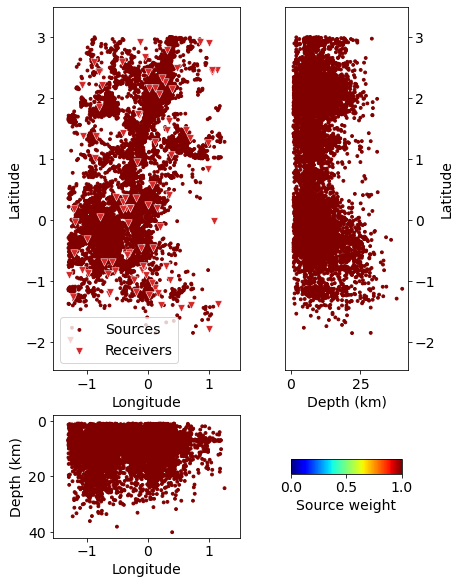

In [4]:
# 读取数据
fname = "output_data/step4_src_rec_cs.dat"

sr = pta.SrcRec.read(fname)

sr.plot(color_by="weight");

# 2. 给地震加权重

有2种权重添加方式：

### (a) box weighting （推荐）

做法是将研究区域按照等间距，划分为很多个小的子区域。每个子区域内的地震数量为 N， 该区域内的地震权重设置为 1 / sqrt(N)。

逻辑是数据更大多的地方，数据总权重还是更大 N * 1 / sqrt(N) = sqrt(N), 但是单个数据的权重更小 1 / sqrt(N)

2026-08-06 11:41:52,871 [SrcRec] INFO: Box weighting for sources: d_deg=0.4, d_km=5


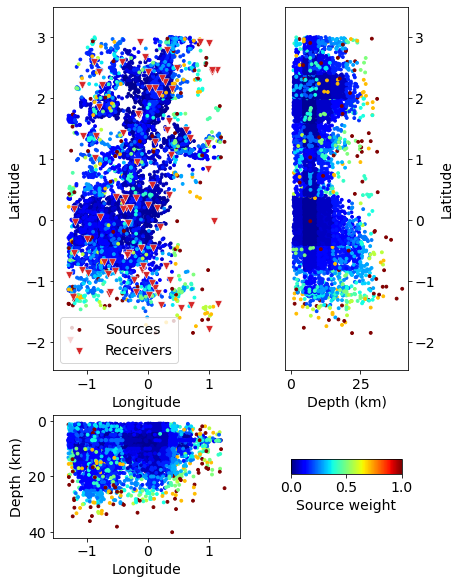

In [5]:
# 子区域的大小为 0.4°×0.4°×5 km, 实施 box weighting
sr_box = sr.copy()

dhori = 0.4; ddep = 5
sr_box.box_weighting(d_deg=dhori, d_km=ddep, obj="src")

# 数据画图，附带权重（可选） fname = None 可以不保存图片
sr_box.plot(color_by="weight");

### (b) geographic weighting （可选）

参考论文

Ruan, Y., Lei, W., Modrak, R., Örsvuran, R., Bozdağ, E., & Tromp, J. (2019). Balancing unevenly distributed data in seismic tomography: a global adjoint tomography example. Geophysical Journal International, 219(2), 1225-1236.

做法是 让每个地震的权重 正相关于 该地震到所有其他地震的距离。

逻辑是，越边缘，地震密度越低的地方，地震距离其他地震的平均距离越大，该地震的权重就越大。

注释1：该权重添加方式比较适合全球成像，在local tomo 里面，在同等数据密度条件下，更容易强化研究区域边缘的地震。（因为研究区域边缘的地震离其他地震的平均距离更远）

注释2：该权重添加方式比 box weighting 更加激进

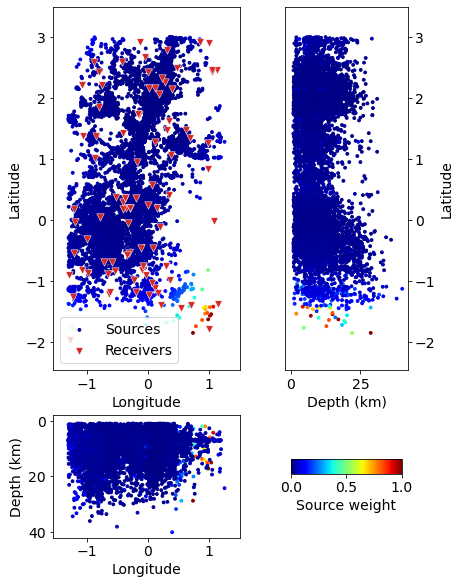

In [6]:
# geographic weighting 
sr_geo = sr.copy()
sr_geo.geo_weighting(scale=0.5, obj="src")

# 权重分布画图 plot weight distribution
sr_geo.plot(color_by="weight");

# 3. 给台站加权重

和给地震增加权重一样，同样有2种添加形式，这里不再赘述

2026-08-06 11:42:41,922 [SrcRec] INFO: Box weighting for receivers: d_deg=0.2


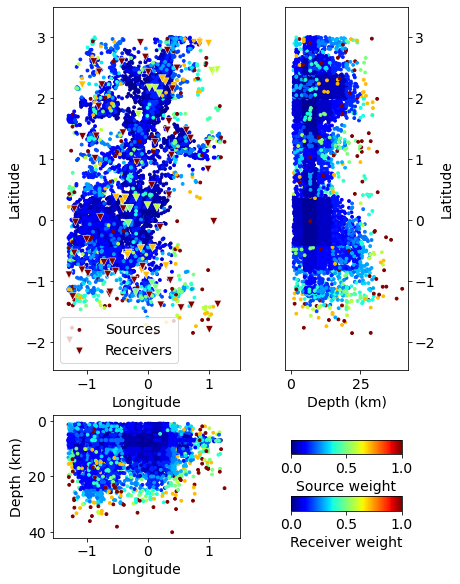

In [7]:
# 给台站加 box weighting
dhori = 0.2
sr_box.box_weighting(d_deg=dhori, obj="rec")

# 权重分布画图
sr_box.plot(color_by="weight", fname = "./figs/step5_ev_st_box_wt.png");

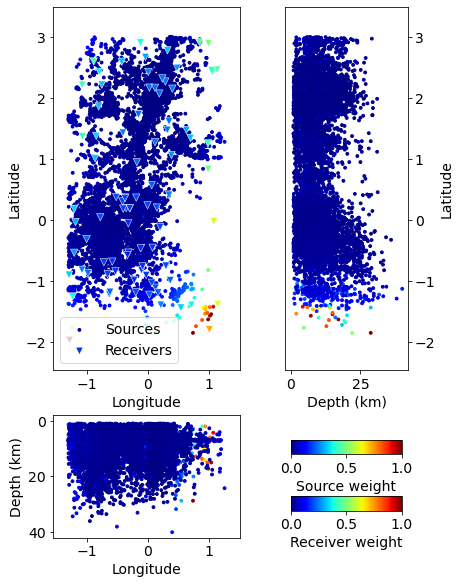

In [8]:
# 给台站加 geographical weighting
sr_geo.geo_weighting(scale=0.5, obj="rec")

# 权重分布画图
sr_geo.plot(color_by="weight", fname = "./figs/step5_ev_st_geo_wt.png");

# 4. 文件输出

In [9]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为 TomoATT格式数据文件
out_fname = f"{out_path}/step5_src_rec_weight.dat"
sr_box.write(out_fname)

# 地震列表，用于画图
out_fname_src = f"{out_path}/step5_ev_list_weight.dat"
sr_box.write_sources(out_fname_src)

# 台站列表，用于画图
out_fname_rec = f"{out_path}/step5_st_list_weight.dat"
sr_box.write_receivers(out_fname_rec)

Writing src_rec file: 100%|██████████| 20644/20644 [00:00<00:00, 82586.24it/s]
